# Uranium-238 (U238) Analysis
## NDA + Machine Learning — Replaced Pin Detection
**Fatima Ballout | Master's Thesis, University of Padova 2023–2024**

---
This notebook trains and evaluates 4 classifiers and 4 regressors on the **Uranium-238 (U238)** isotope scenario.
- **Classification**: Binary — intact (0) vs modified assembly (1)
- **Regression**: Predict number of replaced pins (0–130)

## 1. Imports

In [1]:
import os
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score
)
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 123
TEST_SIZE    = 0.2
N_FOLDS      = 5
DATA_DIR     = '/Users/fatimaballout/desktop/Thesis Work 2'

print('Imports OK')

Imports OK


## 2. Load Data

In [2]:
# Classification dataset
clf_path = os.path.join(DATA_DIR, 'U238_filtered_dataframe_with_file.parquet')
df_clf = pd.read_parquet(clf_path)
print('Classification dataset:', df_clf.shape)
print('MODab_Flag distribution:')
print(df_clf['MODab_Flag'].value_counts().to_frame('Count'))

# Regression dataset  
reg_path = os.path.join(DATA_DIR, 'filtered_dataframe_No_U238.parquet')
df_reg = pd.read_parquet(reg_path)
print('\nRegression dataset:', df_reg.shape)
print('Total Replaced Pins:')
print(df_reg['Total Replaced Pins'].describe().round(2))

Classification dataset: (14898, 67)
MODab_Flag distribution:
   Count
1  12154
0   2744

Regression dataset: (14898, 67)
Total Replaced Pins:
count    14898.00
mean        53.48
std         48.89
min          0.00
25%          7.00
50%         38.00
75%        114.00
max        130.00
Name: Total Replaced Pins, dtype: float64


## 3. Data Overview

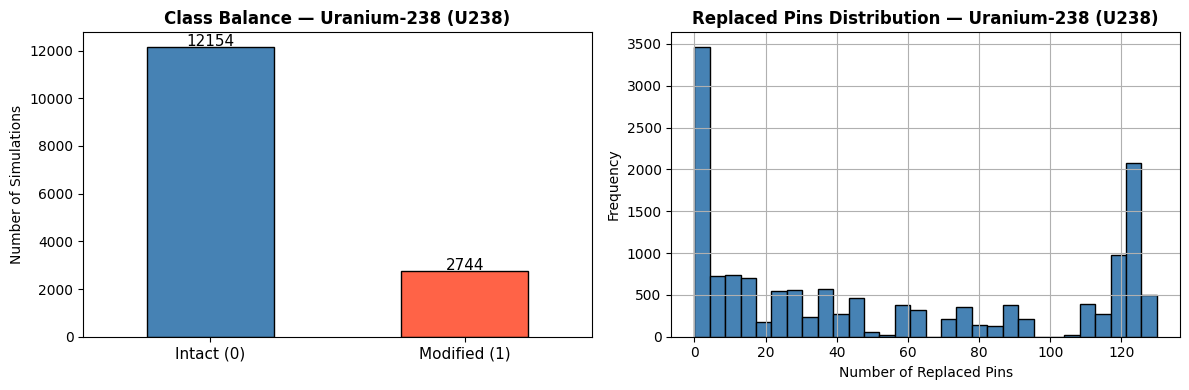

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_clf['MODab_Flag'].value_counts().plot.bar(
    ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_xticklabels(['Intact (0)', 'Modified (1)'], rotation=0, fontsize=11)
axes[0].set_title('Class Balance — Uranium-238 (U238)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Simulations')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(bar.get_height())}', ha='center', fontsize=11)

df_reg['Total Replaced Pins'].hist(ax=axes[1], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Replaced Pins Distribution — Uranium-238 (U238)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Replaced Pins')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('Uranium-238_(U238)_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Helper Functions

In [4]:
def prepare_clf(df):
    cols_drop = ['MODab_Flag']
    for c in df.columns:
        if df[c].dtype == object:
            cols_drop.append(c)
    X = df.drop(columns=list(set(cols_drop)), errors='ignore')
    y = df['MODab_Flag']
    return X, y


def prepare_reg(df):
    cols_drop = ['Total Replaced Pins', 'MODab_Flag']
    for c in df.columns:
        if df[c].dtype == object:
            cols_drop.append(c)
    X = df.drop(columns=list(set(cols_drop)), errors='ignore')
    y = df['Total Replaced Pins']
    return X, y


def cv_classification(model, X, y, n=N_FOLDS):
    skf = StratifiedKFold(n_splits=n, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(model, X, y, cv=skf,
        scoring=['accuracy','precision_weighted','recall_weighted','f1_weighted','roc_auc'])
    return pd.DataFrame({
        'Fold':      range(1, n+1),
        'Accuracy':  scores['test_accuracy'].round(4),
        'Precision': scores['test_precision_weighted'].round(4),
        'Recall':    scores['test_recall_weighted'].round(4),
        'F1':        scores['test_f1_weighted'].round(4),
        'AUC':       scores['test_roc_auc'].round(4),
    })


def cv_regression(model, X, y, n=N_FOLDS):
    kf = KFold(n_splits=n, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(model, X, y, cv=kf,
        scoring=['neg_mean_absolute_error','neg_root_mean_squared_error','r2'])
    return pd.DataFrame({
        'Fold': range(1, n+1),
        'MAE':  (-scores['test_neg_mean_absolute_error']).round(4),
        'RMSE': (-scores['test_neg_root_mean_squared_error']).round(4),
        'R2':   scores['test_r2'].round(4),
    })


def eval_classifier(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    auc  = roc_auc_score(y_te, y_proba)

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1:        {f1:.4f}')
    print(f'  AUC-ROC:   {auc:.4f}')
    print()
    print(classification_report(y_te, y_pred, zero_division=0))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Intact','Modified'], yticklabels=['Intact','Modified'])
    axes[0].set_title(f'Confusion Matrix — {name}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_te, y_proba)
    axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc:.4f}')
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
    axes[1].plot([0,1],[0,1],'k--',lw=1)
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve — {name}', fontsize=12, fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=11)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_clf.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'Model': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1': round(f1,4), 'AUC': round(auc,4)}


def eval_regressor(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  MAE:  {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  R²:   {r2:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].scatter(y_te, y_pred, alpha=0.3, s=8, color='steelblue')
    mn = min(y_te.min(), y_pred.min()); mx = max(y_te.max(), y_pred.max())
    axes[0].plot([mn,mx],[mn,mx],'r--',lw=1.5,label='Perfect fit')
    axes[0].set_xlabel('Actual Replaced Pins'); axes[0].set_ylabel('Predicted Replaced Pins')
    axes[0].set_title(f'Prediction Error — {name}', fontsize=12, fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].text(0.05, 0.92, f'R² = {r2:.4f}\nRMSE = {rmse:.4f}',
                 transform=axes[0].transAxes, fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    residuals = y_te - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.3, s=8, color='tomato')
    axes[1].axhline(0, color='black', lw=1.5, ls='--')
    axes[1].set_xlabel('Predicted Replaced Pins'); axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'Residuals Plot — {name}', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_reg.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'Model': name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R2': round(r2,4)}

print('Helper functions defined.')

Helper functions defined.


## 5. Define Models

In [5]:
classifiers = {
    'Extra Trees Classifier': ExtraTreesClassifier(
        n_estimators=100, criterion='gini', max_depth=None,
        max_features='sqrt', min_samples_leaf=1, min_samples_split=2,
        bootstrap=False, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest Classifier': RandomForestClassifier(
        n_estimators=100, criterion='gini', max_depth=None,
        max_features='sqrt', min_samples_leaf=1, min_samples_split=2,
        bootstrap=True, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'KNN Classifier': KNeighborsClassifier(
        n_neighbors=5, weights='uniform', metric='minkowski'
    ),
    'LGBM Classifier': lgb.LGBMClassifier(
        n_estimators=100, learning_rate=0.1, num_leaves=31,
        class_weight='balanced', random_state=RANDOM_STATE, verbose=-1
    ),
}

regressors = {
    'Extra Trees Regressor': ExtraTreesRegressor(
        n_estimators=100, max_depth=None, max_features='sqrt',
        min_samples_leaf=1, min_samples_split=2,
        bootstrap=False, random_state=RANDOM_STATE
    ),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=100, max_depth=None, max_features='sqrt',
        min_samples_leaf=1, min_samples_split=2,
        bootstrap=True, random_state=RANDOM_STATE
    ),
    'KNN Regressor': KNeighborsRegressor(
        n_neighbors=5, weights='uniform', metric='minkowski'
    ),
    'LGBM Regressor': lgb.LGBMRegressor(
        n_estimators=100, learning_rate=0.1, num_leaves=31,
        random_state=RANDOM_STATE, verbose=-1
    ),
}
print('Models defined.')

Models defined.


## 6. Prepare Train / Test Sets

In [6]:
# Classification
X_clf, y_clf = prepare_clf(df_clf)
scaler_clf   = StandardScaler()
X_clf_sc     = scaler_clf.fit_transform(X_clf)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clf_sc, y_clf, test_size=TEST_SIZE, random_state=42, stratify=y_clf)

print(f'Classification — Train: {X_tr_c.shape}, Test: {X_te_c.shape}')
print(f'Features: {X_clf.shape[1]}')

# Regression
X_reg, y_reg = prepare_reg(df_reg)
scaler_reg   = StandardScaler()
X_reg_sc     = scaler_reg.fit_transform(X_reg)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg_sc, y_reg, test_size=TEST_SIZE, random_state=42)

print(f'\nRegression — Train: {X_tr_r.shape}, Test: {X_te_r.shape}')

Classification — Train: (11918, 65), Test: (2980, 65)
Features: 65

Regression — Train: (11918, 65), Test: (2980, 65)


## 7. Classification — Uranium-238 (U238)
**Task:** Predict whether the fuel assembly has replaced pins (0=intact, 1=modified)

### 7.1 Extra Trees Classifier

In [7]:
# Cross-Validation
print('--- Extra Trees Classifier | 5-Fold Cross-Validation ---')
cv_df = cv_classification(copy.deepcopy(classifiers['Extra Trees Classifier']), X_clf_sc, y_clf)
print(cv_df.to_string(index=False))
print(f'Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')
print(f'Mean AUC:      {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')

--- Extra Trees Classifier | 5-Fold Cross-Validation ---
 Fold  Accuracy  Precision  Recall     F1    AUC
    1    0.9963     0.9963  0.9963 0.9963 0.9999
    2    0.9983     0.9983  0.9983 0.9983 0.9999
    3    0.9973     0.9973  0.9973 0.9973 0.9982
    4    0.9983     0.9983  0.9983 0.9983 0.9999
    5    0.9963     0.9963  0.9963 0.9963 0.9993
Mean Accuracy: 0.9973 ± 0.0010
Mean AUC:      0.9994 ± 0.0007



  Extra Trees Classifier
  Accuracy:  0.9980
  Precision: 0.9980
  Recall:    0.9980
  F1:        0.9980
  AUC-ROC:   0.9997

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       549
           1       1.00      1.00      1.00      2431

    accuracy                           1.00      2980
   macro avg       1.00      1.00      1.00      2980
weighted avg       1.00      1.00      1.00      2980



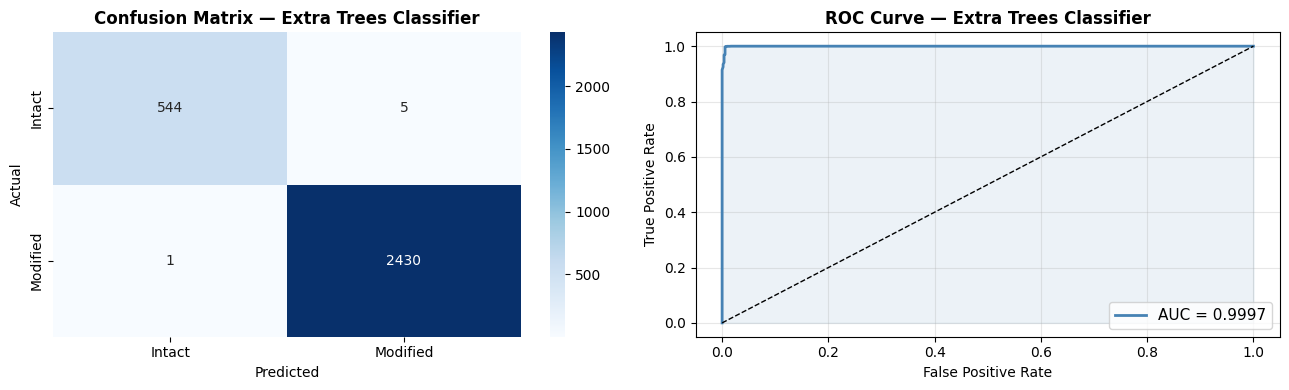

In [8]:
# Train & Evaluate
result_extra_trees_classifier = eval_classifier(
    copy.deepcopy(classifiers['Extra Trees Classifier']),
    X_tr_c, X_te_c, y_tr_c, y_te_c, 'Extra Trees Classifier'
)

### 7.2 Random Forest Classifier

In [9]:
# Cross-Validation
print('--- Random Forest Classifier | 5-Fold Cross-Validation ---')
cv_df = cv_classification(copy.deepcopy(classifiers['Random Forest Classifier']), X_clf_sc, y_clf)
print(cv_df.to_string(index=False))
print(f'Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')
print(f'Mean AUC:      {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')

--- Random Forest Classifier | 5-Fold Cross-Validation ---
 Fold  Accuracy  Precision  Recall     F1    AUC
    1    0.9909     0.9909  0.9909 0.9909 0.9993
    2    0.9926     0.9926  0.9926 0.9926 0.9984
    3    0.9936     0.9936  0.9936 0.9936 0.9963
    4    0.9933     0.9933  0.9933 0.9933 0.9996
    5    0.9896     0.9896  0.9896 0.9896 0.9986
Mean Accuracy: 0.9920 ± 0.0017
Mean AUC:      0.9984 ± 0.0013



  Random Forest Classifier
  Accuracy:  0.9940
  Precision: 0.9940
  Recall:    0.9940
  F1:        0.9940
  AUC-ROC:   0.9994

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       549
           1       1.00      1.00      1.00      2431

    accuracy                           0.99      2980
   macro avg       0.99      0.99      0.99      2980
weighted avg       0.99      0.99      0.99      2980



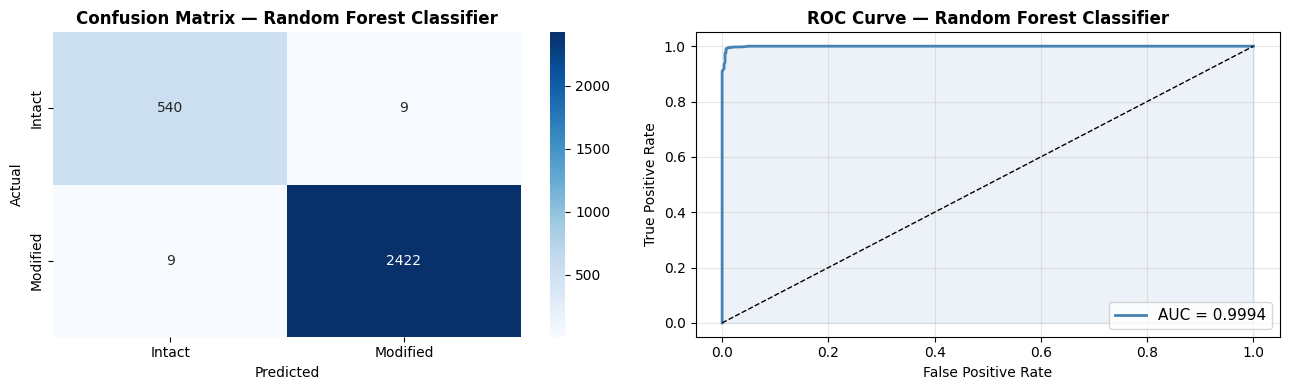

In [10]:
# Train & Evaluate
result_random_forest_classifier = eval_classifier(
    copy.deepcopy(classifiers['Random Forest Classifier']),
    X_tr_c, X_te_c, y_tr_c, y_te_c, 'Random Forest Classifier'
)

### 7.3 KNN Classifier

In [11]:
# Cross-Validation
print('--- KNN Classifier | 5-Fold Cross-Validation ---')
cv_df = cv_classification(copy.deepcopy(classifiers['KNN Classifier']), X_clf_sc, y_clf)
print(cv_df.to_string(index=False))
print(f'Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')
print(f'Mean AUC:      {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')

--- KNN Classifier | 5-Fold Cross-Validation ---
 Fold  Accuracy  Precision  Recall     F1    AUC
    1    0.9537     0.9624  0.9537 0.9555 0.9935
    2    0.9460     0.9580  0.9460 0.9485 0.9917
    3    0.9517     0.9609  0.9517 0.9536 0.9909
    4    0.9470     0.9588  0.9470 0.9494 0.9926
    5    0.9439     0.9568  0.9439 0.9466 0.9931
Mean Accuracy: 0.9485 ± 0.0041
Mean AUC:      0.9924 ± 0.0011



  KNN Classifier
  Accuracy:  0.9527
  Precision: 0.9620
  Recall:    0.9527
  F1:        0.9546
  AUC-ROC:   0.9909

              precision    recall  f1-score   support

           0       0.80      1.00      0.89       549
           1       1.00      0.94      0.97      2431

    accuracy                           0.95      2980
   macro avg       0.90      0.97      0.93      2980
weighted avg       0.96      0.95      0.95      2980



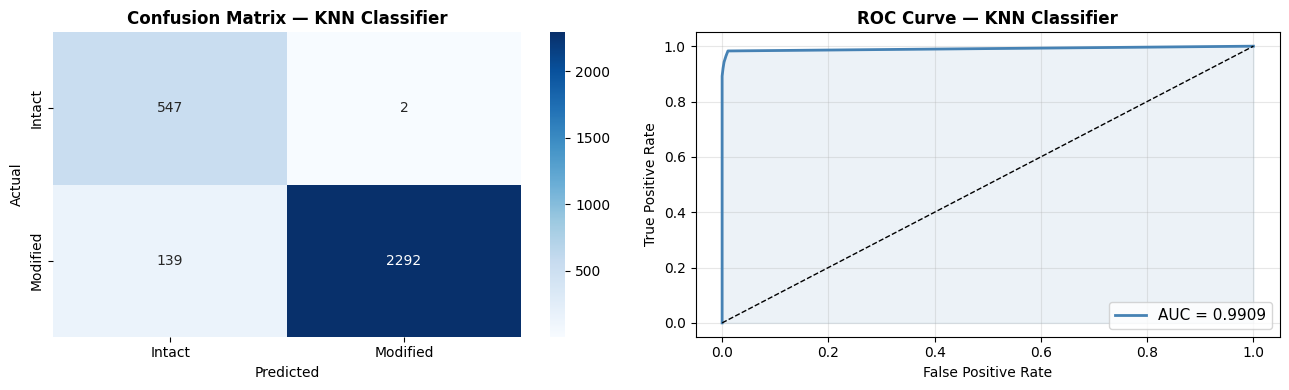

In [12]:
# Train & Evaluate
result_knn_classifier = eval_classifier(
    copy.deepcopy(classifiers['KNN Classifier']),
    X_tr_c, X_te_c, y_tr_c, y_te_c, 'KNN Classifier'
)

### 7.4 LGBM Classifier

In [13]:
# Cross-Validation
print('--- LGBM Classifier | 5-Fold Cross-Validation ---')
cv_df = cv_classification(copy.deepcopy(classifiers['LGBM Classifier']), X_clf_sc, y_clf)
print(cv_df.to_string(index=False))
print(f'Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')
print(f'Mean AUC:      {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')

--- LGBM Classifier | 5-Fold Cross-Validation ---
 Fold  Accuracy  Precision  Recall     F1    AUC
    1    0.9728     0.9757  0.9728 0.9734 0.9982
    2    0.9721     0.9748  0.9721 0.9728 0.9974
    3    0.9758     0.9774  0.9758 0.9762 0.9979
    4    0.9742     0.9766  0.9742 0.9747 0.9988
    5    0.9701     0.9726  0.9701 0.9707 0.9972
Mean Accuracy: 0.9730 ± 0.0022
Mean AUC:      0.9979 ± 0.0006



  LGBM Classifier
  Accuracy:  0.9762
  Precision: 0.9781
  Recall:    0.9762
  F1:        0.9766
  AUC-ROC:   0.9982

              precision    recall  f1-score   support

           0       0.89      0.99      0.94       549
           1       1.00      0.97      0.99      2431

    accuracy                           0.98      2980
   macro avg       0.95      0.98      0.96      2980
weighted avg       0.98      0.98      0.98      2980



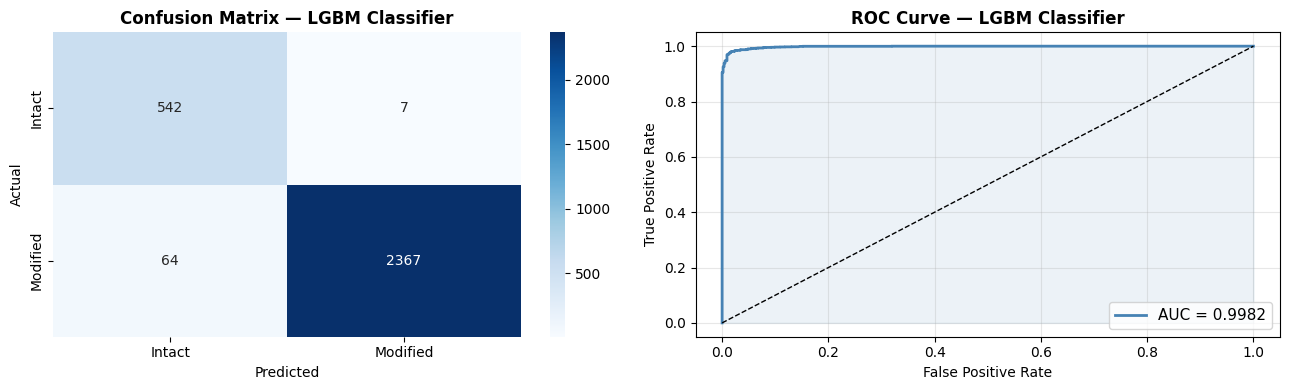

In [14]:
# Train & Evaluate
result_lgbm_classifier = eval_classifier(
    copy.deepcopy(classifiers['LGBM Classifier']),
    X_tr_c, X_te_c, y_tr_c, y_te_c, 'LGBM Classifier'
)

### 7.5 Classification Summary

                   Model  Accuracy  Precision  Recall     F1    AUC
  Extra Trees Classifier    0.9980     0.9980  0.9980 0.9980 0.9997
Random Forest Classifier    0.9940     0.9940  0.9940 0.9940 0.9994
          KNN Classifier    0.9527     0.9620  0.9527 0.9546 0.9909
         LGBM Classifier    0.9762     0.9781  0.9762 0.9766 0.9982


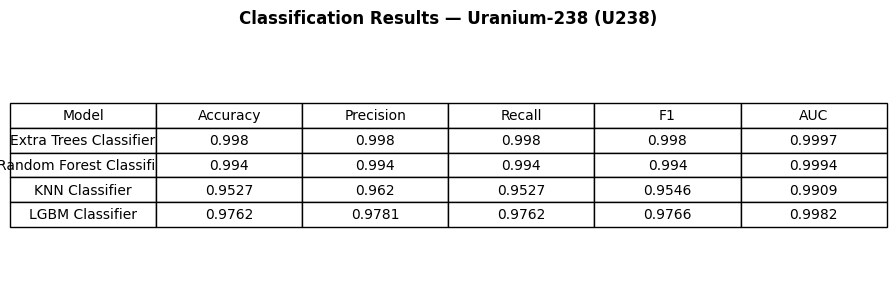

In [15]:
clf_summary = pd.DataFrame([
    result_extra_trees_classifier,
    result_random_forest_classifier,
    result_knn_classifier,
    result_lgbm_classifier,
])
print(clf_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')
tbl = ax.table(cellText=clf_summary.values, colLabels=clf_summary.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.5)
plt.title(f'Classification Results — Uranium-238 (U238)', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('classification_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Regression — Uranium-238 (U238)
**Task:** Predict the exact number of replaced pins (0–130)

### 8.1 Extra Trees Regressor

In [16]:
# Cross-Validation
print('--- Extra Trees Regressor | 5-Fold Cross-Validation ---')
cv_df = cv_regression(copy.deepcopy(regressors['Extra Trees Regressor']), X_reg_sc, y_reg)
print(cv_df.to_string(index=False))
print(f'Mean MAE:  {cv_df["MAE"].mean():.4f} ± {cv_df["MAE"].std():.4f}')
print(f'Mean RMSE: {cv_df["RMSE"].mean():.4f} ± {cv_df["RMSE"].std():.4f}')
print(f'Mean R²:   {cv_df["R2"].mean():.4f} ± {cv_df["R2"].std():.4f}')

--- Extra Trees Regressor | 5-Fold Cross-Validation ---
 Fold    MAE    RMSE     R2
    1 6.0949 10.3078 0.9553
    2 5.9842 10.1601 0.9566
    3 5.9374 10.1562 0.9577
    4 6.2186 10.3824 0.9553
    5 6.2392 10.4378 0.9534
Mean MAE:  6.0949 ± 0.1353
Mean RMSE: 10.2889 ± 0.1279
Mean R²:   0.9557 ± 0.0016



  Extra Trees Regressor
  MAE:  5.7459
  RMSE: 9.7222
  R²:   0.9612


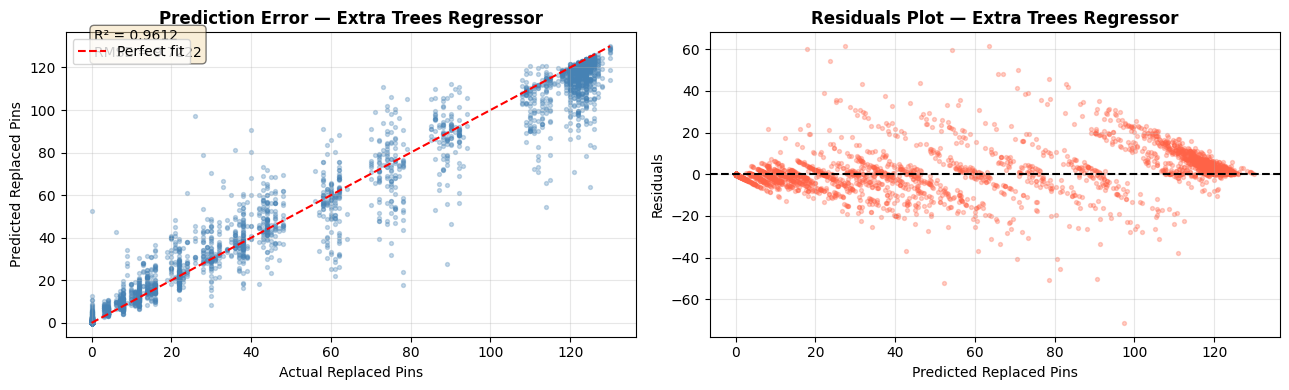

In [17]:
# Train & Evaluate
result_extra_trees_regressor = eval_regressor(
    copy.deepcopy(regressors['Extra Trees Regressor']),
    X_tr_r, X_te_r, y_tr_r, y_te_r, 'Extra Trees Regressor'
)

### 8.2 Random Forest Regressor

In [18]:
# Cross-Validation
print('--- Random Forest Regressor | 5-Fold Cross-Validation ---')
cv_df = cv_regression(copy.deepcopy(regressors['Random Forest Regressor']), X_reg_sc, y_reg)
print(cv_df.to_string(index=False))
print(f'Mean MAE:  {cv_df["MAE"].mean():.4f} ± {cv_df["MAE"].std():.4f}')
print(f'Mean RMSE: {cv_df["RMSE"].mean():.4f} ± {cv_df["RMSE"].std():.4f}')
print(f'Mean R²:   {cv_df["R2"].mean():.4f} ± {cv_df["R2"].std():.4f}')

--- Random Forest Regressor | 5-Fold Cross-Validation ---
 Fold    MAE    RMSE     R2
    1 7.1338 11.3795 0.9455
    2 6.9558 11.1330 0.9479
    3 6.9624 11.2328 0.9483
    4 7.0905 11.1994 0.9480
    5 7.2103 11.3698 0.9447
Mean MAE:  7.0706 ± 0.1104
Mean RMSE: 11.2629 ± 0.1082
Mean R²:   0.9469 ± 0.0017



  Random Forest Regressor
  MAE:  6.7376
  RMSE: 10.8203
  R²:   0.9519


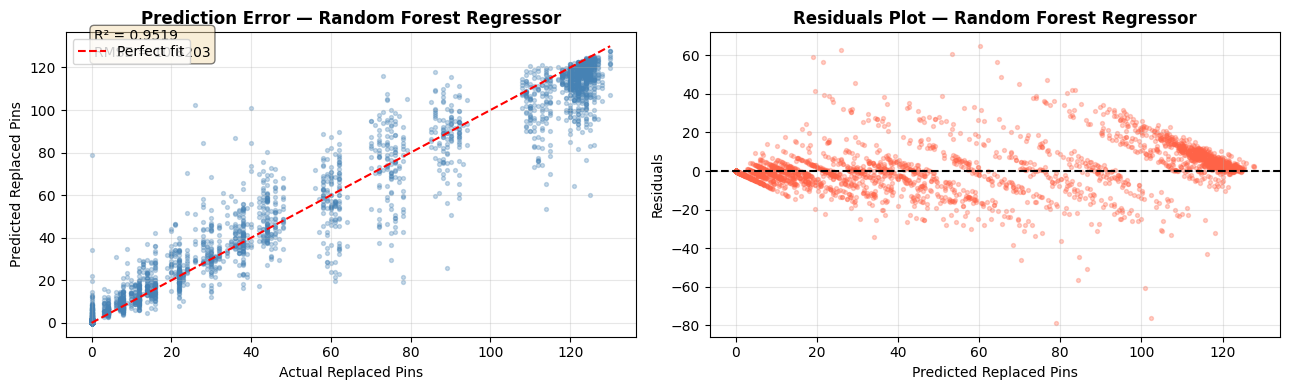

In [19]:
# Train & Evaluate
result_random_forest_regressor = eval_regressor(
    copy.deepcopy(regressors['Random Forest Regressor']),
    X_tr_r, X_te_r, y_tr_r, y_te_r, 'Random Forest Regressor'
)

### 8.3 KNN Regressor

In [20]:
# Cross-Validation
print('--- KNN Regressor | 5-Fold Cross-Validation ---')
cv_df = cv_regression(copy.deepcopy(regressors['KNN Regressor']), X_reg_sc, y_reg)
print(cv_df.to_string(index=False))
print(f'Mean MAE:  {cv_df["MAE"].mean():.4f} ± {cv_df["MAE"].std():.4f}')
print(f'Mean RMSE: {cv_df["RMSE"].mean():.4f} ± {cv_df["RMSE"].std():.4f}')
print(f'Mean R²:   {cv_df["R2"].mean():.4f} ± {cv_df["R2"].std():.4f}')

--- KNN Regressor | 5-Fold Cross-Validation ---
 Fold    MAE    RMSE     R2
    1 9.3633 16.8430 0.8807
    2 8.9095 16.1362 0.8905
    3 9.2695 16.7028 0.8857
    4 9.8391 17.7345 0.8697
    5 9.4984 17.0872 0.8752
Mean MAE:  9.3760 ± 0.3386
Mean RMSE: 16.9007 ± 0.5824
Mean R²:   0.8804 ± 0.0082



  KNN Regressor
  MAE:  9.0308
  RMSE: 16.3808
  R²:   0.8898


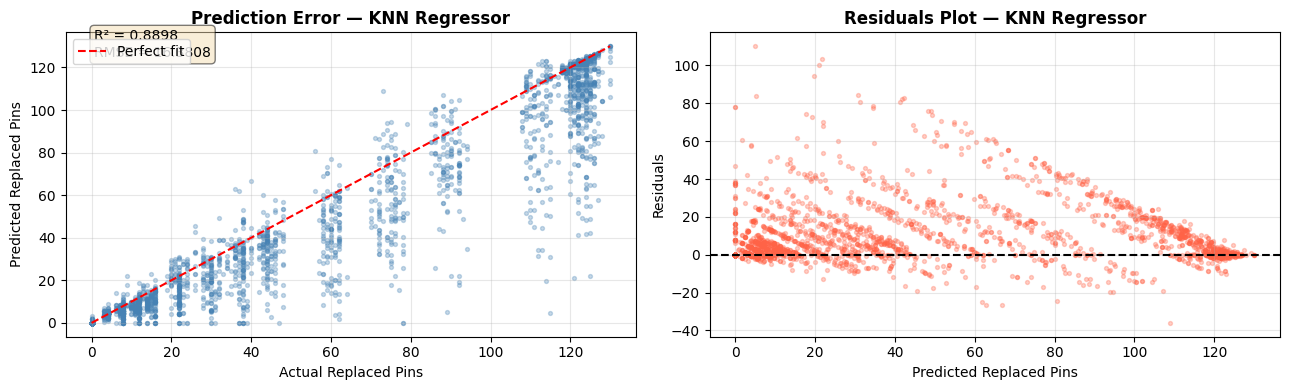

In [21]:
# Train & Evaluate
result_knn_regressor = eval_regressor(
    copy.deepcopy(regressors['KNN Regressor']),
    X_tr_r, X_te_r, y_tr_r, y_te_r, 'KNN Regressor'
)

### 8.4 LGBM Regressor

In [22]:
# Cross-Validation
print('--- LGBM Regressor | 5-Fold Cross-Validation ---')
cv_df = cv_regression(copy.deepcopy(regressors['LGBM Regressor']), X_reg_sc, y_reg)
print(cv_df.to_string(index=False))
print(f'Mean MAE:  {cv_df["MAE"].mean():.4f} ± {cv_df["MAE"].std():.4f}')
print(f'Mean RMSE: {cv_df["RMSE"].mean():.4f} ± {cv_df["RMSE"].std():.4f}')
print(f'Mean R²:   {cv_df["R2"].mean():.4f} ± {cv_df["R2"].std():.4f}')

--- LGBM Regressor | 5-Fold Cross-Validation ---
 Fold    MAE    RMSE     R2
    1 8.1589 12.3841 0.9355
    2 8.0831 12.5926 0.9333
    3 7.7921 12.1124 0.9399
    4 7.8663 12.0198 0.9401
    5 7.9529 12.1541 0.9369
Mean MAE:  7.9707 ± 0.1510
Mean RMSE: 12.2526 ± 0.2326
Mean R²:   0.9371 ± 0.0029



  LGBM Regressor
  MAE:  7.6404
  RMSE: 11.7918
  R²:   0.9429


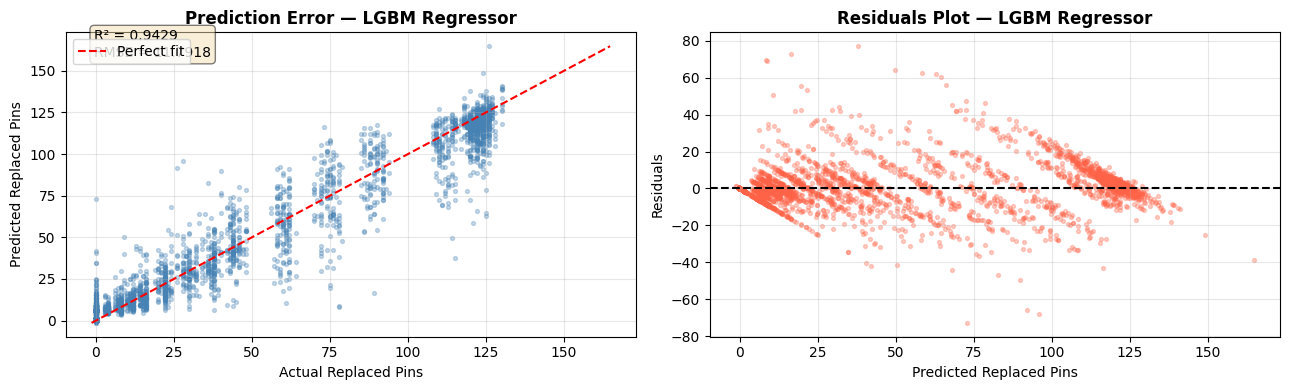

In [23]:
# Train & Evaluate
result_lgbm_regressor = eval_regressor(
    copy.deepcopy(regressors['LGBM Regressor']),
    X_tr_r, X_te_r, y_tr_r, y_te_r, 'LGBM Regressor'
)

### 8.5 Regression Summary

                  Model    MAE    RMSE     R2
  Extra Trees Regressor 5.7459  9.7222 0.9612
Random Forest Regressor 6.7376 10.8203 0.9519
          KNN Regressor 9.0308 16.3808 0.8898
         LGBM Regressor 7.6404 11.7918 0.9429


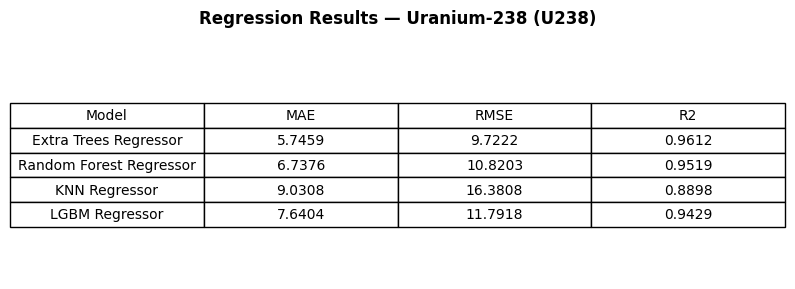

In [24]:
reg_summary = pd.DataFrame([
    result_extra_trees_regressor,
    result_random_forest_regressor,
    result_knn_regressor,
    result_lgbm_regressor,
])
print(reg_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
tbl = ax.table(cellText=reg_summary.values, colLabels=reg_summary.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.5)
plt.title(f'Regression Results — Uranium-238 (U238)', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('regression_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Export Results

In [25]:
with pd.ExcelWriter('Uranium-238_(U238)_results.xlsx') as writer:
    clf_summary.to_excel(writer, sheet_name='Classification', index=False)
    reg_summary.to_excel(writer, sheet_name='Regression', index=False)

print('Results saved to Uranium-238_(U238)_results.xlsx')

Results saved to Uranium-238_(U238)_results.xlsx
